# MLP Proof of Concept — Citation Impact Prediction

Binary classification: predict whether a CS paper falls in the
top 10% of citations within its publication year cohort.

**Model:** Two-layer MLP implemented from scratch using NumPy only.  
**Architecture:** input → hidden (ReLU) -> output (sigmoid)  
**Target:** `high_impact` (1 if cited_by_count >= 90th percentile within year)

In [10]:
# setup + imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [11]:
# load dataset
df = pd.read_csv("../data/processed/dataset.csv")

FEATURE_COLS = [
    "log_num_authors",
    "log_num_institutions",
    "log_num_countries",
    "is_multi_institution",
    "is_international",
    "has_elite_affiliation",
    "has_industry",
    "has_gov_nonprofit",
    "has_us_institution",
    "is_open_access",
    "is_journal",
]

X = df[FEATURE_COLS].values.astype(float)
y = df["high_impact"].values.astype(float)

# standardize
mu, sigma = X.mean(axis=0), X.std(axis=0)
sigma[sigma == 0] = 1
X = (X - mu) / sigma

# 80/20 train/test split 
idx = np.random.permutation(len(X))
cut = int(len(X) * 0.8)
X_train, X_test = X[idx[:cut]], X[idx[cut:]]
y_train, y_test = y[idx[:cut]], y[idx[cut:]]

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Positive class (train): {y_train.mean():.3f}")

Train: 4225 | Test: 1057
Positive class (train): 0.107


## Features + Target

In [12]:
FEATURE_COLS = [
    "log_num_authors",
    "log_num_institutions",
    "log_num_countries",
    "is_multi_institution",
    "is_international",
    "has_elite_affiliation",
    "has_industry",
    "has_gov_nonprofit",
    "has_us_institution",
    "is_open_access",
    "is_journal",
]
TARGET_COL = "high_impact"

X = df[FEATURE_COLS].values.astype(float)
y = df[TARGET_COL].values.astype(float)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (5282, 11)
y shape: (5282,)


## Model

In [20]:
# helpers
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return np.heaviside(z, 0)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # ~9.0

def bce_loss(y, y_hat):
    y_hat = np.clip(y_hat, 1e-10, 1 - 1e-10)
    weights = np.where(y == 1, pos_weight, 1.0)
    return -np.mean(weights * (y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)))

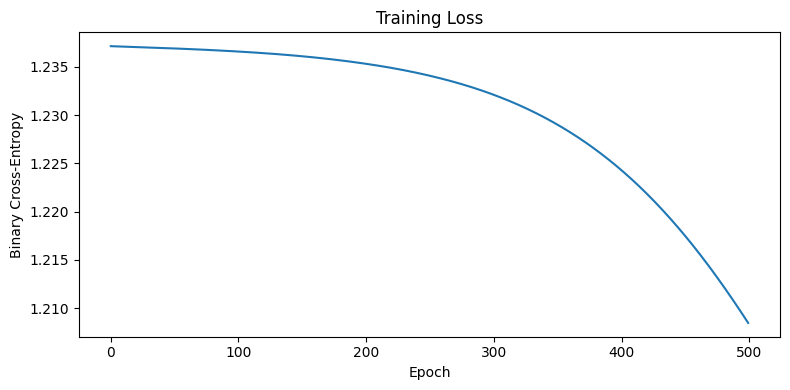

In [21]:
# training loop 
n, d  = X_train.shape
q = 16 
eta   = 0.01
epochs = 500

# weights
W1 = np.random.randn(d, q) * 0.01
W2 = np.random.randn(q, 1) * 0.01

losses = []

for epoch in range(epochs):
    # forward pass
    Z1   = X_train @ W1
    H    = relu(Z1)
    Z2   = H @ W2
    yhat = sigmoid(Z2).flatten()

    loss = bce_loss(y_train, yhat)
    losses.append(loss)

    # backwards pass
    weights = np.where(y_train == 1, pos_weight, 1.0)
    err  = (weights * (yhat - y_train)) / n
    dW2  = H.T @ err.reshape(-1, 1)
    dH   = err.reshape(-1, 1) * W2.T
    dW1  = X_train.T @ (dH * relu_deriv(Z1))

    W1  -= eta * dW1
    W2  -= eta * dW2

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.title("Training Loss")
plt.tight_layout()
plt.show()

## Evaluation

In [22]:
def predict(X, threshold=0.5):
    H    = relu(X @ W1)
    yhat = sigmoid(H @ W2).flatten()
    return (yhat >= threshold).astype(int)

y_pred = predict(X_test)
acc = np.mean(y_test == y_pred)

tp = np.sum((y_test == 1) & (y_pred == 1))
tn = np.sum((y_test == 0) & (y_pred == 0))
fp = np.sum((y_test == 0) & (y_pred == 1))
fn = np.sum((y_test == 1) & (y_pred == 0))

print(f"Accuracy : {acc:.4f}")
print(f"\nConfusion Matrix:")
print(f"              Pred 0   Pred 1")
print(f"  Actual 0    {tn:5d}    {fp:5d}")
print(f"  Actual 1    {fn:5d}    {tp:5d}")

Accuracy : 0.5658

Confusion Matrix:
              Pred 0   Pred 1
  Actual 0      523      438
  Actual 1       21       75
